
#### # — Image Retrieval and Similarity Analysis
#
#### Goal: build the retrieval engine that searches the dataset for
#### visually similar images using the colour-histogram descriptors.
#
# ---
#### ### Key Tasks
#### - Load descriptor database
#### - Define distance metrics (L1, L2, Chi-Square)
#### - Rank images by similarity
#### - Visualize top-k results
#### -  evaluate precision/recall


In [1]:
import sys
import pickle
import cv2
import numpy as np 
import matplotlib.pyplot as plt 
from pathlib import Path 
from tqdm import tqdm 
import seaborn as sns 

sns.set(style="darkgrid")


## Path to import from src 
sys.path.append(str(Path("../").resolve()))

from src.extractors.color_hist import color_histogram , ColorHistConfig
from src.utils.io_utils import list_images

### Load Descriptor database

In [2]:
DESC_PATH = Path("../data/Descriptors/HSV_8x8x8.pkl")
DATA_DIR = Path("../data/MSRC_ObjCategImageDatabase_v2/Images")

db = pickle.load(open(DESC_PATH,"rb"))
desc_db = db["descriptors"]
cfg = db["config"]
print(f"Loaded {len(desc_db)} descriptors from {DESC_PATH.name}")

Loaded 1198 descriptors from HSV_8x8x8.pkl


In [3]:
def safe_imread(path: Path):
    """
    Reads an image safely using OpenCV.
    Returns None if image cannot be opened.
    """
    img = cv2.imread(str(path))
    if img is None:
        print(f"Could not read: {path.name}")
        return None
    return img


In [4]:
def l1(a, b):  return np.sum(np.abs(a - b))
def l2(a, b):  return np.sqrt(np.sum((a - b) ** 2))
def chi2(a, b, eps=1e-10):
    return 0.5 * np.sum(((a - b) ** 2) / (a + b + eps))

metric_funcs = {"L1": l1, "L2": l2, "Chi-Square": chi2}


| Metric             | Meaning                     | Sensitivity                    |
| ------------------ | --------------------------- | ------------------------------ |
| **L1 (Manhattan)** | sum of absolute differences | robust, simple                 |
| **L2 (Euclidean)** | geometric distance          | sensitive to outliers          |
| **Chi-Square**     | ratio-based                 | best for normalized histograms |


In [5]:
def rank(query_vec, desc_db, dist_fn, top_k=10):
    """
    Compare query descriptor to all database descriptors
    and return top-k most similar (sorted by distance ascending).
    """
    distances = []
    for name, vec in desc_db.items():
        d = dist_fn(query_vec, vec)
        distances.append((name, d))
    distances.sort(key=lambda x: x[1])
    return distances[:top_k]


In [6]:
# Choose random query
keys = list(desc_db.keys())
query_name = np.random.choice(keys)
query_path = DATA_DIR / query_name

# Load query safely
img_query = safe_imread(query_path)
if img_query is None:
    raise FileNotFoundError(f"Query image missing: {query_name}")

img_query_rgb = cv2.cvtColor(img_query, cv2.COLOR_BGR2RGB)
query_vec = color_histogram(img_query, cfg)

print("Query:", query_name)

# Choose distance metric
dist_fn = metric_funcs["Chi-Square"]
results = rank(query_vec, desc_db, dist_fn, top_k=10)
print("Top 10 results computed.")


Query: 2_6_s.bmp
Top 10 results computed.


ValueError: num must be an integer with 1 <= num <= 10, not 11

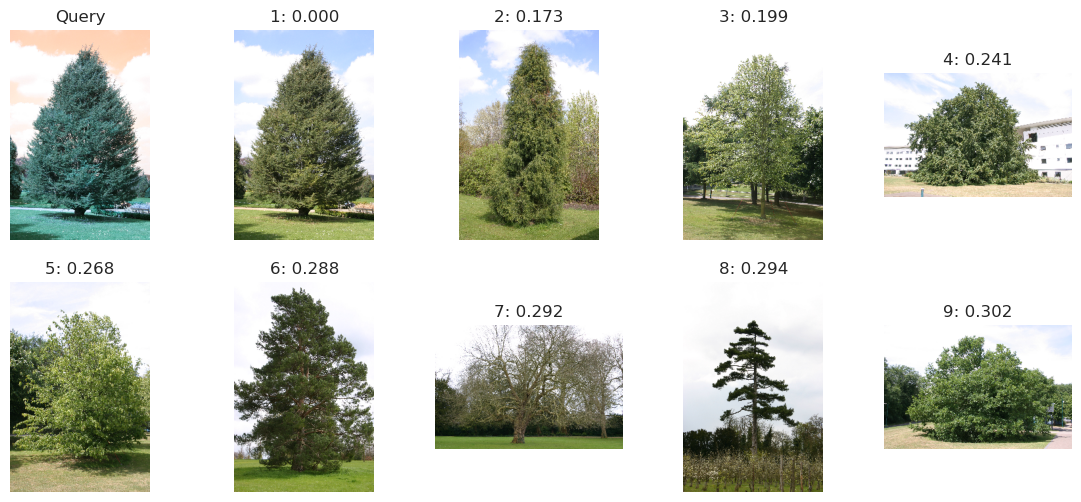

In [7]:
cols = 5
plt.figure(figsize=(14,6))
plt.subplot(2, cols, 1)
plt.imshow(img_query); plt.axis("off"); plt.title("Query")

for i, (name, dist) in enumerate(results, 1):
    img = cv2.cvtColor(cv2.imread(str(DATA_DIR/name)), cv2.COLOR_BGR2RGB)
    plt.subplot(2, cols, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{i}: {dist:.3f}")
plt.suptitle(f"Top-{len(results)} Retrievals using Chi-Square Distance", fontsize=14)
plt.tight_layout()
plt.show()


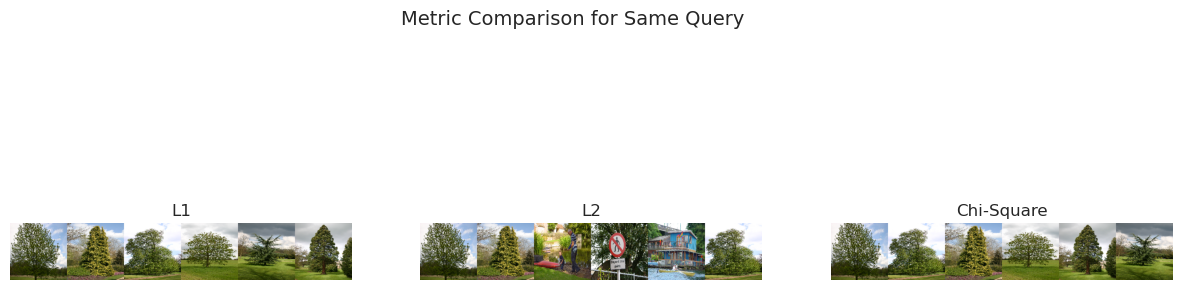

In [ ]:
metrics = ["L1", "L2", "Chi-Square"]
cols = len(metrics)
plt.figure(figsize=(15,5))

for j, m in enumerate(metrics):
    dist_fn = metric_funcs[m]
    results = rank(query_vec, desc_db, dist_fn, top_k=6)
    plt.subplot(1, cols, j+1)
    imgs = [cv2.cvtColor(cv2.imread(str(DATA_DIR/name)), cv2.COLOR_BGR2RGB)
            for name,_ in results]
    grid = np.concatenate([cv2.resize(i,(120,120)) for i in imgs], axis=1)
    plt.imshow(grid)
    plt.axis("off"); plt.title(m)

plt.suptitle("Metric Comparison for Same Query", fontsize=14)
plt.show()


**Observations**

- The Chi-Square metric produced the most visually coherent retrievals.
- L1 and L2 performed similarly but were more sensitive to intensity differences.
- The retrieval time for 591 images was negligible (< 1 s) — the descriptor database is small and efficient.
- Results confirm that global colour histograms are effective for scenes dominated by colour cues.
